In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import BECancerResistome
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy.stats import zscore, pearsonr, gaussian_kde, chi2_contingency

In [43]:
def boxplot_conditions(df):
    _, ax = plt.subplots(figsize=(3, 2))

    sns.boxplot(
        data=df,
        orient="h",
        linewidth=0.3,
        fliersize=1,
        notch=True,
        saturation=1.0,
        showcaps=False,
        boxprops=dict(linewidth=0.5, edgecolor="black"),
        whiskerprops=dict(linewidth=0.5, color="black"),
        flierprops=dict(
            marker="o",
            markerfacecolor="black",
            markersize=1.0,
            linestyle="none",
            markeredgecolor="none",
            alpha=0.6,
        ),
        medianprops=dict(linestyle="-", linewidth=0.5),
        ax=ax,
    )

    return ax

## Import sgRNAs information


In [44]:
be_guides = pd.read_csv(
    "data/1_Beagle_design_files/EG/EG-guides.txt", sep="\t", index_col=0
)
be_guides = be_guides[be_guides["Edit Type"] == "C-T"]
be_guides["Edit Type"] = be_guides["Edit Type"].replace("C-T", "CBE")
be_guides = be_guides.set_index(["sgRNA Sequence", "Target Gene Symbol", "Edit Type"])
be_guides["aa_change"] = be_guides["Amino Acid Edits"].apply(
    BECancerResistome.convert_amino_acid_variants
)
be_guides

,,,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Context Sequence,...,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,aa_change
sgRNA Sequence,Target Gene Symbol,Edit Type,,,,,,,,,,,,,,,,,,,,,
CGCATCGCTGCTCCCCGAAG,EGFR,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,GGGTCGCATCGCTGCTCCCCGAAGAGCTCG,...,55019263,antisense,"55019275G>A, 55019277G>A","C_8, C_6","-3G>A, -1G>A","(NC), (NC)","UTR, UTR",NaN,NaN,
GTCGCATCGCTGCTCCCCGA,EGFR,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,GAGGGTCGCATCGCTGCTCCCCGAAGAGCT,...,55019265,antisense,"55019277G>A, 55019280G>A","C_8, C_5","-1G>A, 3G>A","(NC), Met1Ile","UTR, Missense",NaN,NaN,M1I
AGGGTCGCATCGCTGCTCCC,EGFR,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,CCGGAGGGTCGCATCGCTGCTCCCCGAAGA,...,55019268,antisense,"55019280G>A, 55019282G>A","C_8, C_6","3G>A, 5G>A","Met1Ile, Arg2Gln","Missense, Missense",NaN,NaN,"M1I, R2Q"
GGAGCAGCGATGCGACCCTC,EGFR,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,TCGGGGAGCAGCGATGCGACCCTCCGGGAC,...,55019269,sense,"55019273C>T, 55019276C>T","C_5, C_8","-5C>T, -2C>T","(NC), (NC)","UTR, UTR",NaN,NaN,
GAGCAGCGATGCGACCCTCC,EGFR,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,CGGGGAGCAGCGATGCGACCCTCCGGGACG,...,55019270,sense,"55019273C>T, 55019276C>T","C_4, C_7","-5C>T, -2C>T","(NC), (NC)","UTR, UTR",NaN,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGATCAGGCATTGTATGACG,PGD,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000142657,+,ENST00000270776.13,CDS,AGCATGATCAGGCATTGTATGACGAGGATG,...,10419733,antisense,10419748G>A,C_5,1451G>A,Ter484Ter,Silent,NaN,NaN,*484*
CATGATCAGGCATTGTATGA,PGD,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000142657,+,ENST00000270776.13,CDS,GCAGCATGATCAGGCATTGTATGACGAGGA,...,10419735,antisense,10419748G>A,C_7,1451G>A,Ter484Ter,Silent,NaN,NaN,*484*
CATACAATGCCTGATCATGC,PGD,CBE,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000142657,+,ENST00000270776.13,CDS,TCGTCATACAATGCCTGATCATGCTGCTCC,...,10419736,sense,10419740C>T,C_5,1443C>T,Tyr481Tyr,Silent,NaN,NaN,Y481Y


## Import replicate log FC


### EG


In [45]:
eg_lfc = pd.read_csv("data/5_LFC/EG/EG_LFC_rep_control.csv", index_col=(0, 1, 2))
eg_lfc

,,,A375_RDA270_CP2165_PIC_RepA,A375_RDA270_CP2165_PIC_RepB,A375_RDA270_CP2165_SCH_RepA,A375_RDA270_CP2165_SCH_RepB,A375_RDA270_CP2165_LIN_RepA,A375_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB
Guide,Gene,Editor,,,,,,,,,,,,
AAAAGCCAAGTCTGAGACTG,ITGA3,CBE,0.452928,-0.808171,2.998783,-2.448053,0.472156,-0.875869,0.001659,-0.304153,-0.578337,0.153671,-0.667815,1.341586
AAACCAAAGGCAGAGCCACT,ITGA3,CBE,0.217013,0.677794,-2.746959,0.207902,0.207029,0.635205,0.108289,-0.162985,-0.674230,0.296882,-0.547715,-0.628420
AAACTGTGGAGGATGTAGGA,ITGA3,CBE,0.002161,-0.322403,-1.286051,-2.766199,0.333987,-1.664943,0.270610,-0.047729,-0.398517,0.003310,-0.679497,-0.804045
AACAAGACCACGTGGGTGAG,ITGA3,CBE,-0.066317,-0.115419,-3.352100,-3.236738,-0.142245,-0.364678,0.034386,-0.150981,-0.778644,0.092328,-0.574848,-0.244479
AACATCACAGTGAAAAGTGA,ITGA3,CBE,-0.811406,0.184296,0.367144,0.371154,0.573433,0.949500,-0.010587,-0.093788,-0.568424,-0.306394,1.538513,-0.622495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTATAGGCGCACGTTCGTTG,Intergenic control,CBE,-0.634884,0.920280,-0.040030,2.287473,-0.265970,0.805044,-0.148161,-0.012270,-0.978463,0.048061,-0.940755,-0.669342
GTATGAATATATCGCGCGAC,Intergenic control,CBE,0.705553,-0.383681,-2.714939,1.994679,-0.217591,-0.044173,0.275161,-0.138058,-0.362126,0.089988,-0.228624,-0.891897
CGACGCTAACGCGTCGGAAT,Intergenic control,CBE,0.036427,-0.394896,-1.938883,1.698022,0.734694,0.022881,0.064307,0.221764,-0.646186,0.041726,-0.575103,-0.694884


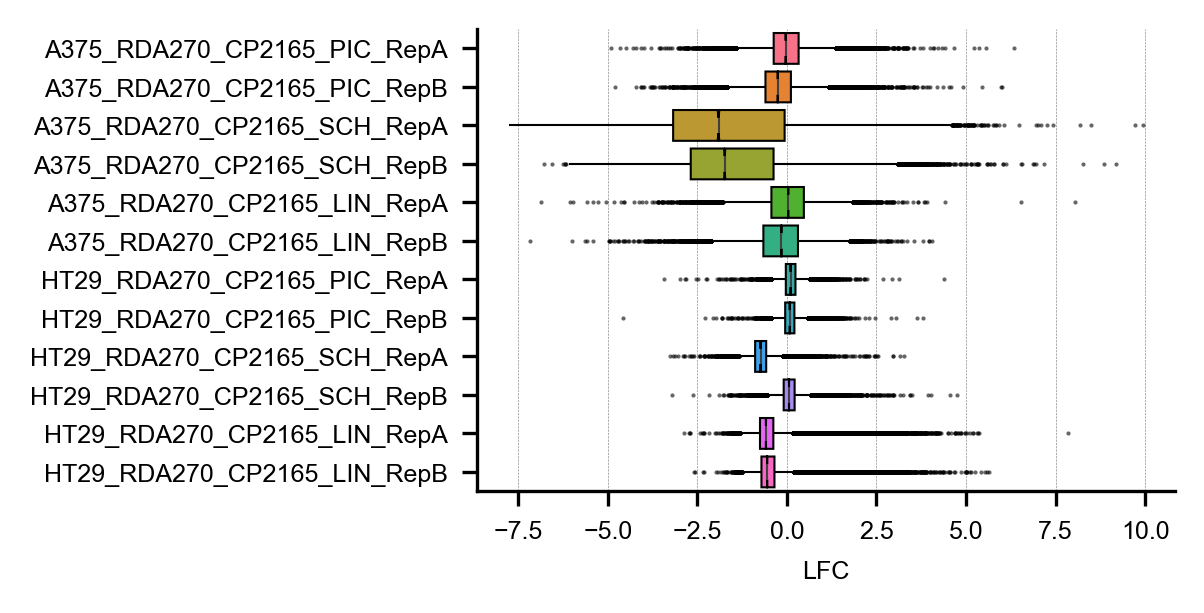

In [46]:
ax = boxplot_conditions(eg_lfc)
ax.set_xlabel("LFC")
plt.show()
plt.close("all")

#### Controls


In [78]:
eg_lfc_pdna = pd.read_csv("data/5_LFC/EG/EG_LFC_rep_pDNA.csv", index_col=(0, 1, 2))
eg_lfc_pdna

,,,A375_RDA270_CP2165_PIC_RepA,A375_RDA270_CP2165_PIC_RepB,A375_RDA270_CP2165_SCH_RepA,A375_RDA270_CP2165_SCH_RepB,A375_RDA270_CP2165_LIN_RepA,A375_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB
Guide,Gene,Editor,,,,,,,,,,,,
AAAAGCCAAGTCTGAGACTG,ITGA3,CBE,2.505796,1.458411,4.776699,-0.456421,2.250073,1.115762,1.682723,1.854489,0.842801,2.052388,0.753322,3.240303
AAACCAAAGGCAGAGCCACT,ITGA3,CBE,2.003320,3.580246,-1.176380,2.894625,1.777608,3.321928,1.510070,1.291105,0.704282,1.727703,0.830796,0.802400
AAACTGTGGAGGATGTAGGA,ITGA3,CBE,1.979846,1.521709,0.784857,-0.828864,2.404895,0.272392,1.965010,2.013191,1.217395,1.985743,0.936415,1.178388
AACAAGACCACGTGGGTGAG,ITGA3,CBE,1.312049,1.315857,-1.966141,-1.797870,1.243714,1.074191,1.879196,1.834625,0.646579,1.658346,0.850375,1.321539
AACATCACAGTGAAAAGTGA,ITGA3,CBE,1.192776,1.893568,2.235537,1.944636,2.441826,2.522982,1.530424,1.606834,0.984442,1.406082,3.091379,1.089981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTATAGGCGCACGTTCGTTG,Intergenic control,CBE,1.207484,3.290992,1.594270,4.450117,1.368330,2.967688,1.694951,1.689826,0.710824,1.596332,0.748532,0.878929
GTATGAATATATCGCGCGAC,Intergenic control,CBE,1.013675,1.057904,-2.484386,3.358695,0.012962,1.319843,1.309775,1.062329,0.669307,1.287194,0.802808,0.305308
CGACGCTAACGCGTCGGAAT,Intergenic control,CBE,1.613465,1.391995,-0.511305,3.335452,2.162271,1.660311,1.749263,1.988729,0.998180,1.768101,1.069263,1.031491


In [79]:
eg_lfc_controls = eg_lfc_pdna.loc[
    eg_lfc.index.get_level_values(1).map(
        lambda x: x in ["Panlethal splice donor", "Intergenic control"]
    )
]
eg_lfc_controls = eg_lfc_controls.reset_index().melt(
    id_vars=eg_lfc_controls.index.names
)
eg_lfc_controls

,Guide,Gene,Editor,variable,value
0,ATTACCTGGTTGTCAAGCAG,Panlethal splice donor,CBE,A375_RDA270_CP2165_PIC_RepA,0.375197
1,CATTACCTGGTTGTCAAGCA,Panlethal splice donor,CBE,A375_RDA270_CP2165_PIC_RepA,-1.289030
2,GAATTCTACCTTCTTCATCA,Panlethal splice donor,CBE,A375_RDA270_CP2165_PIC_RepA,1.907530
3,AAGTTACCTGATTACAATCC,Panlethal splice donor,CBE,A375_RDA270_CP2165_PIC_RepA,1.292641
4,ACTTACCCTGGCATGTTTCA,Panlethal splice donor,CBE,A375_RDA270_CP2165_PIC_RepA,0.439606
...,...,...,...,...,...
12859,CTATAGGCGCACGTTCGTTG,Intergenic control,CBE,HT29_RDA270_CP2165_LIN_RepB,0.878929
12860,GTATGAATATATCGCGCGAC,Intergenic control,CBE,HT29_RDA270_CP2165_LIN_RepB,0.305308
12861,CGACGCTAACGCGTCGGAAT,Intergenic control,CBE,HT29_RDA270_CP2165_LIN_RepB,1.031491
12862,TGGTAGTACTACGACGATAG,Intergenic control,CBE,HT29_RDA270_CP2165_LIN_RepB,2.280180


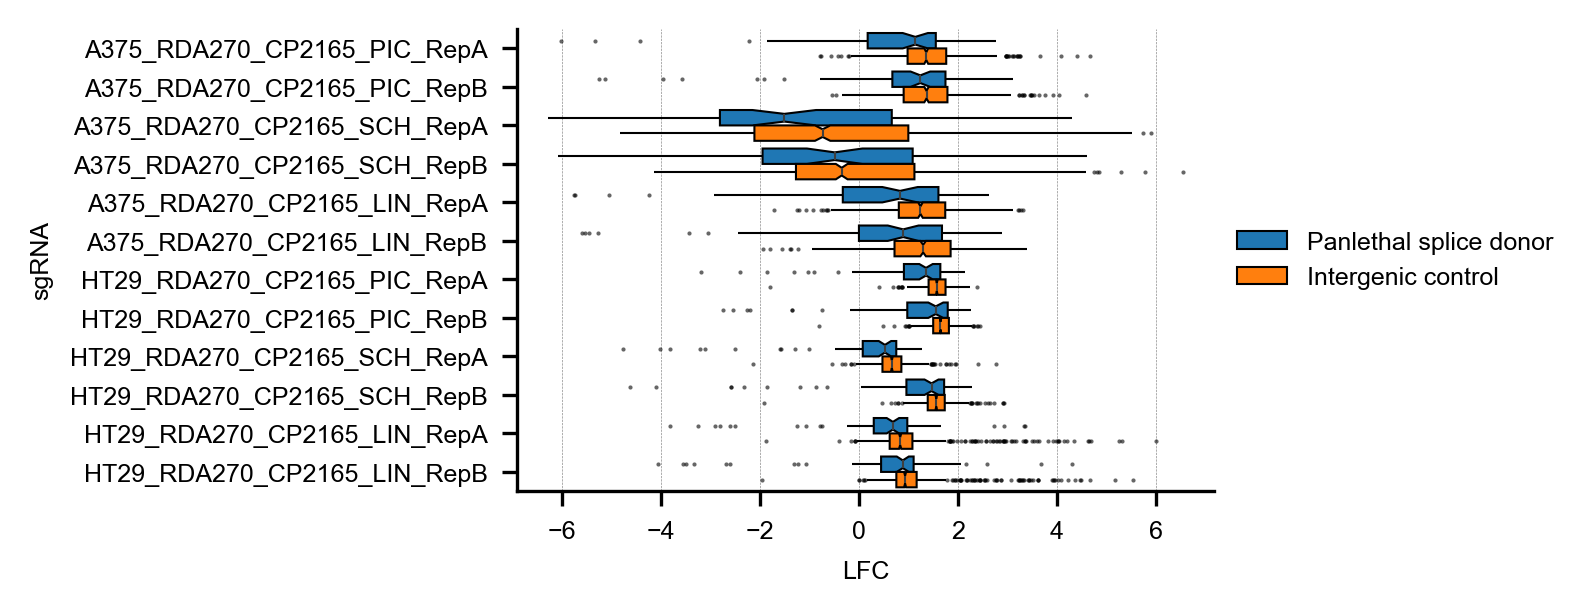

In [80]:
_, ax = plt.subplots(figsize=(3, 2))

sns.boxplot(
    data=eg_lfc_controls,
    x="value",
    y="variable",
    hue="Gene",
    orient="h",
    linewidth=0.3,
    fliersize=1,
    notch=True,
    saturation=1.0,
    showcaps=False,
    boxprops=dict(linewidth=0.5, edgecolor="black"),
    whiskerprops=dict(linewidth=0.5, color="black"),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markersize=1.0,
        linestyle="none",
        markeredgecolor="none",
        alpha=0.6,
    ),
    medianprops=dict(linestyle="-", linewidth=0.5),
    ax=ax,
)

ax.set_xlabel("LFC")
ax.set_ylabel("sgRNA")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    title="",
    title_fontsize=2,
    fontsize=6,
    frameon=False,
)
plt.show()
plt.close("all")

### MC


In [49]:
mc_lfc = pd.read_csv("data/5_LFC/MC/MC_LFC_rep_control.csv", index_col=(0, 1, 2))
mc_lfc

H_23_Adag_RepA  H_23_Adag_RepB  \
Guide                Gene Editor                                   
AAAAAAAAAAACTAAGAGTT KRAS ABE           1.357983        0.033749   
                          CBE          -0.877355        0.172344   
AAAAAAAAAAGTAAGCTTCA KRAS ABE          -0.717526        0.022961   
                          CBE          -0.208798        0.123515   
AAAAAAAAAATCAATGGTGG BCL2 ABE          -0.690744       -0.086232   
...                                          ...             ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE          -0.505579       -0.106668   
TTTTGTGTGACAAAGCGTAA EGFR ABE           0.858408        0.009373   
                          CBE          -0.810505        0.040441   
TTTTGTTTCCTTGCTCACTG BRAF ABE           0.031429       -0.182739   
                          CBE           0.228294        0.056043   

                                  H_23_Sotor_RepA  H_23_Sotor_RepB  \
Guide                Gene Editor                                     
AAAAAAAAAAACTAAGAGTT KRAS ABE            0.348764         0.004262   
                          CBE           -0.130256         0.038704   
AAAAAAAAAAGTAAGCTTCA KRAS ABE           -0.832313         0.048052   
                          CBE            0.230266        -0.242230   
AAAAAAAAAATCAATGGTGG BCL2 ABE           -1.658058         0.334674   
...                                           ...              ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE           -0.137586        -0.122904   
TTTTGTGTGACAAAGCGTAA EGFR ABE            1.560002         0.116097   
                          CBE           -0.320213        -0.403823   
TTTTGTTTCCTTGCTCACTG BRAF ABE           -0.365708         0.298545   
                          CBE            0.086215        -0.279238   

                                  H_23_T0_RepA  H_23_T0_RepB  HT_29_Pict_RepA  \
Guide                Gene Editor                                                
AAAAAAAAAAACTAAGAGTT KRAS ABE         0.575115     -0.021501         0.038381   
                          CBE         0.860246      0.152875        -0.038474   
AAAAAAAAAAGTAAGCTTCA KRAS ABE        -0.388443     -0.477221         0.440573   
                          CBE         0.070662      0.060505        -0.447138   
AAAAAAAAAATCAATGGTGG BCL2 ABE        -1.184127      0.193260         0.546326   
...                                        ...           ...              ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE        -0.155744     -0.257262        -0.119164   
TTTTGTGTGACAAAGCGTAA EGFR ABE         0.481533     -0.138041         0.153069   
                          CBE        -0.042965     -0.101174         0.444926   
TTTTGTTTCCTTGCTCACTG BRAF ABE        -0.567293      0.054620         0.338193   
                          CBE        -0.121041     -0.183573        -0.174482   

                                  HT_29_Pict_RepB  HT_29_T0_RepA  \
Guide                Gene Editor                                   
AAAAAAAAAAACTAAGAGTT KRAS ABE            0.408232       0.188662   
                          CBE            0.119937       0.263825   
AAAAAAAAAAGTAAGCTTCA KRAS ABE           -0.233690       0.481215   
                          CBE            0.010647      -0.541531   
AAAAAAAAAATCAATGGTGG BCL2 ABE            0.445206       0.341459   
...                                           ...            ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE            0.016643      -0.098144   
TTTTGTGTGACAAAGCGTAA EGFR ABE            0.056399       0.151698   
                          CBE            0.149645      -0.088974   
TTTTGTTTCCTTGCTCACTG BRAF ABE            0.015414       0.676845   
                          CBE            0.118895      -0.179470   

                                  HT_29_T0_RepB  HT_29_Tram_RepA  \
Guide                Gene Editor                                   
AAAAAAAAAAACTAAGAGTT KRAS ABE         -0.146357        -0.192645   
                          CBE          0.541127         0.399531   
AAAAAAAAAAGTAAGCTTCA KRAS A

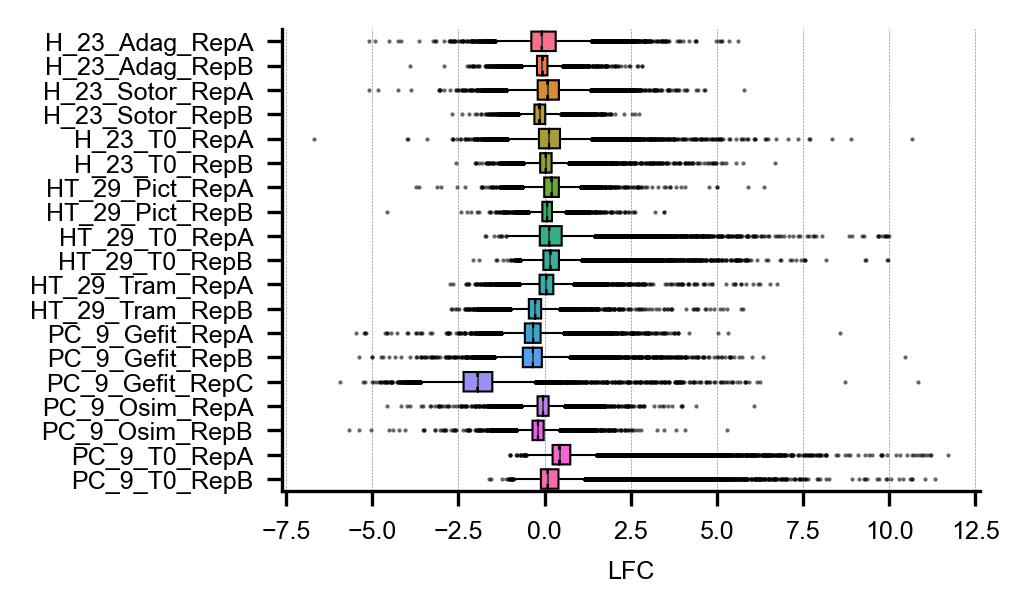

In [50]:
ax = boxplot_conditions(mc_lfc)
ax.set_xlabel("LFC")
plt.show()
plt.close("all")

## Standardize


In [51]:
eg_lfc_zscore = eg_lfc.apply(zscore, axis=0)
eg_lfc_zscore

,,,A375_RDA270_CP2165_PIC_RepA,A375_RDA270_CP2165_PIC_RepB,A375_RDA270_CP2165_SCH_RepA,A375_RDA270_CP2165_SCH_RepB,A375_RDA270_CP2165_LIN_RepA,A375_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB
Guide,Gene,Editor,,,,,,,,,,,,
AAAAGCCAAGTCTGAGACTG,ITGA3,CBE,0.726458,-0.912276,2.162223,-0.603496,0.648129,-0.894018,-0.443943,-1.711943,0.479106,0.255251,-0.351546,2.649645
AAACCAAAGGCAGAGCCACT,ITGA3,CBE,0.349377,1.397269,-0.594202,0.950604,0.281075,1.077359,0.008810,-1.089595,0.161447,0.720976,-0.168518,-0.362280
AAACTGTGGAGGATGTAGGA,ITGA3,CBE,0.005962,-0.157276,0.106644,-0.789655,0.456841,-1.923461,0.698036,-0.581483,1.074788,-0.233727,-0.369348,-0.630790
AACAAGACCACGTGGGTGAG,ITGA3,CBE,-0.103491,0.164427,-0.884509,-1.064986,-0.202475,-0.227108,-0.304985,-1.036672,-0.184440,0.055762,-0.209868,0.224724
AACATCACAGTGAAAAGTGA,ITGA3,CBE,-1.294425,0.630256,0.899738,1.046129,0.788341,1.487394,-0.495942,-0.784534,0.511946,-1.240892,3.010805,-0.353220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTATAGGCGCACGTTCGTTG,Intergenic control,CBE,-1.012276,1.774150,0.704402,2.167440,-0.373766,1.298934,-1.080088,-0.425157,-0.846374,-0.088197,-0.767495,-0.424845
GTATGAATATATCGCGCGAC,Intergenic control,CBE,1.130247,-0.252516,-0.578841,1.996115,-0.306788,0.191029,0.717361,-0.979702,1.195339,0.048151,0.317763,-0.765107
CGACGCTAACGCGTCGGAAT,Intergenic control,CBE,0.060731,-0.269948,-0.206541,1.822530,1.011597,0.278509,-0.177936,0.606592,0.254346,-0.108798,-0.210256,-0.463895


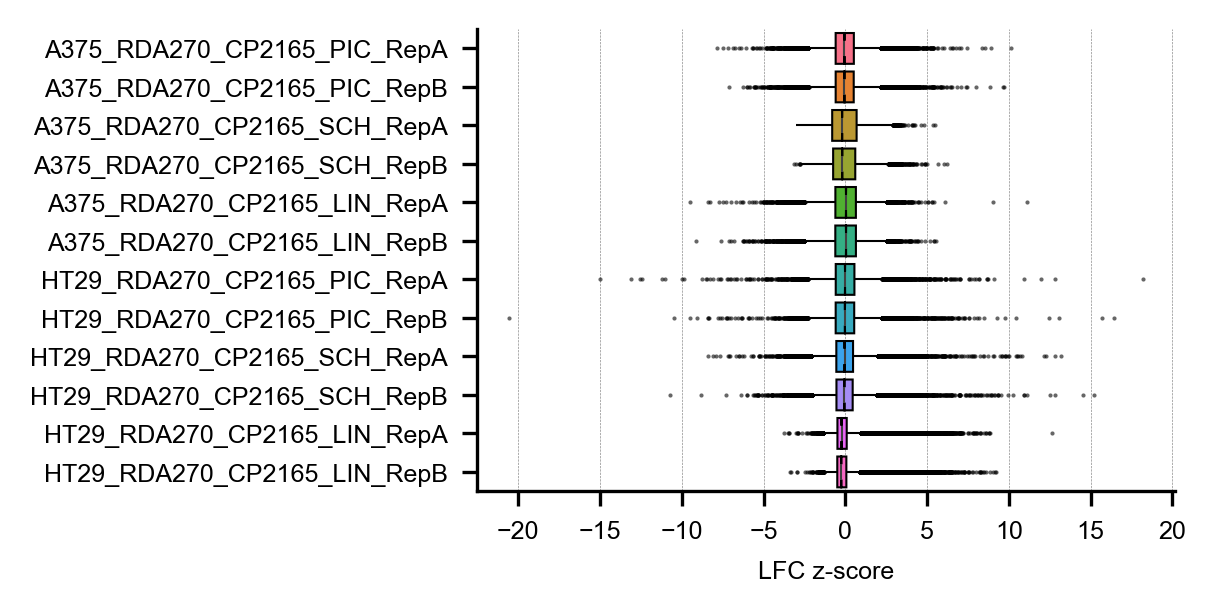

In [52]:
ax = boxplot_conditions(eg_lfc_zscore)
ax.set_xlabel("LFC z-score")
plt.show()
plt.close("all")

In [53]:
mc_lfc_zscore = mc_lfc.apply(zscore, axis=0)
mc_lfc_zscore

H_23_Adag_RepA  H_23_Adag_RepB  \
Guide                Gene Editor                                   
AAAAAAAAAAACTAAGAGTT KRAS ABE           2.207348        0.402865   
                          CBE          -1.449757        0.918930   
AAAAAAAAAAGTAAGCTTCA KRAS ABE          -1.188269        0.362697   
                          CBE          -0.355971        0.737111   
AAAAAAAAAATCAATGGTGG BCL2 ABE          -1.144453       -0.043889   
...                                          ...             ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE          -0.841516       -0.119981   
TTTTGTGTGACAAAGCGTAA EGFR ABE           1.390022        0.312099   
                          CBE          -1.340387        0.427783   
TTTTGTTTCCTTGCTCACTG BRAF ABE           0.037052       -0.403233   
                          CBE           0.359130        0.485878   

                                  H_23_Sotor_RepA  H_23_Sotor_RepB  \
Guide                Gene Editor                                     
AAAAAAAAAAACTAAGAGTT KRAS ABE            0.380066         0.498364   
                          CBE           -0.479683         0.626715   
AAAAAAAAAAGTAAGCTTCA KRAS ABE           -1.739739         0.661554   
                          CBE            0.167385        -0.420225   
AAAAAAAAAATCAATGGTGG BCL2 ABE           -3.221789         1.729693   
...                                           ...              ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE           -0.492837         0.024459   
TTTTGTGTGACAAAGCGTAA EGFR ABE            2.554001         0.915134   
                          CBE           -0.820618        -1.022426   
TTTTGTTTCCTTGCTCACTG BRAF ABE           -0.902272         1.595054   
                          CBE           -0.091159        -0.558143   

                                  H_23_T0_RepA  H_23_T0_RepB  HT_29_Pict_RepA  \
Guide                Gene Editor                                                
AAAAAAAAAAACTAAGAGTT KRAS ABE         0.679483     -0.234905        -0.463185   
                          CBE         1.157486      0.264746        -0.682689   
AAAAAAAAAAGTAAGCTTCA KRAS ABE        -0.935857     -1.540713         0.685501   
                          CBE        -0.166199      0.000072        -1.849862   
AAAAAAAAAATCAATGGTGG BCL2 ABE        -2.269767      0.380467         0.987539   
...                                        ...           ...              ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE        -0.545753     -0.910449        -0.913146   
TTTTGTGTGACAAAGCGTAA EGFR ABE         0.522599     -0.568835        -0.135629   
                          CBE        -0.356686     -0.463197         0.697934   
TTTTGTTTCCTTGCTCACTG BRAF ABE        -1.235687     -0.016791         0.393098   
                          CBE        -0.487575     -0.699302        -1.071137   

                                  HT_29_Pict_RepB  HT_29_T0_RepA  \
Guide                Gene Editor                                   
AAAAAAAAAAACTAAGAGTT KRAS ABE            1.404888      -0.128870   
                          CBE            0.185809      -0.020508   
AAAAAAAAAAGTAAGCTTCA KRAS ABE           -1.309531       0.292900   
                          CBE           -0.276330      -1.181579   
AAAAAAAAAATCAATGGTGG BCL2 ABE            1.561234       0.091417   
...                                           ...            ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE           -0.250978      -0.542353   
TTTTGTGTGACAAAGCGTAA EGFR ABE           -0.082865      -0.182159   
                          CBE            0.311432      -0.529133   
TTTTGTTTCCTTGCTCACTG BRAF ABE           -0.256172       0.574937   
                          CBE            0.181405      -0.659600   

                                  HT_29_T0_RepB  HT_29_Tram_RepA  \
Guide                Gene Editor                                   
AAAAAAAAAAACTAAGAGTT KRAS ABE         -0.734249        -0.689808   
                          CBE          0.468743         0.893712   
AAAAAAAAAAGTAAGCTTCA KRAS A

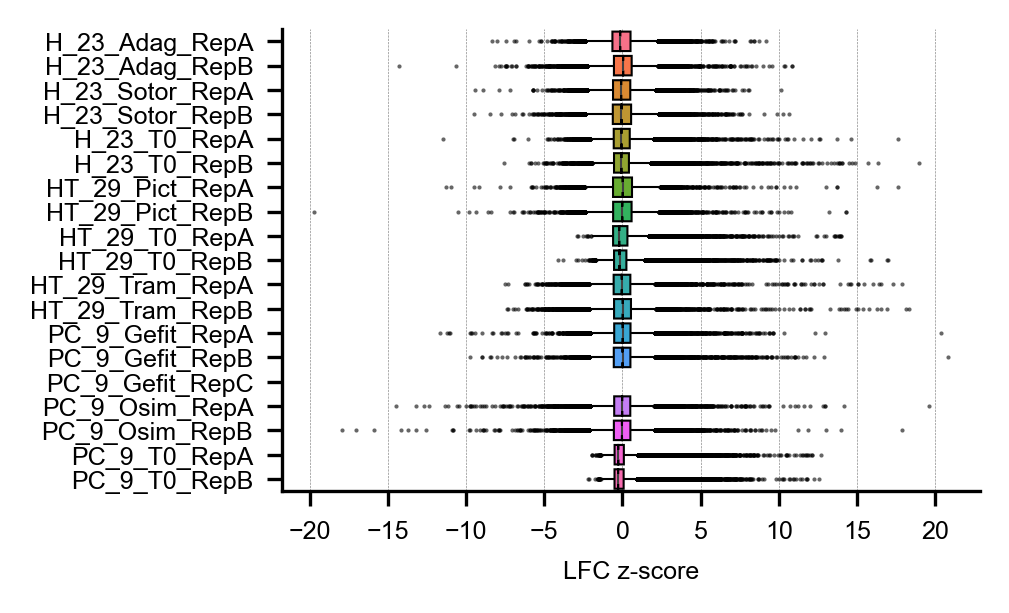

In [54]:
ax = boxplot_conditions(mc_lfc_zscore)
ax.set_xlabel("LFC z-score")
plt.show()
plt.close("all")

## Replicate averaging


In [55]:
eg_lfc_zscore_min = eg_lfc_zscore.groupby(
    eg_lfc_zscore.columns.str.rsplit("_", n=1).str[0], axis=1
).agg(lambda r: r.apply(lambda v: min(v, key=abs), axis=1))
eg_lfc_zscore_min

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_54582/4167503603.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  eg_lfc_zscore_min = eg_lfc_zscore.groupby(


,,,A375_RDA270_CP2165_LIN,A375_RDA270_CP2165_PIC,A375_RDA270_CP2165_SCH,HT29_RDA270_CP2165_LIN,HT29_RDA270_CP2165_PIC,HT29_RDA270_CP2165_SCH
Guide,Gene,Editor,,,,,,
AAAAGCCAAGTCTGAGACTG,ITGA3,CBE,0.648129,0.726458,-0.603496,-0.351546,-0.443943,0.255251
AAACCAAAGGCAGAGCCACT,ITGA3,CBE,0.281075,0.349377,-0.594202,-0.168518,0.008810,0.161447
AAACTGTGGAGGATGTAGGA,ITGA3,CBE,0.456841,0.005962,0.106644,-0.369348,-0.581483,-0.233727
AACAAGACCACGTGGGTGAG,ITGA3,CBE,-0.202475,-0.103491,-0.884509,-0.209868,-0.304985,0.055762
AACATCACAGTGAAAAGTGA,ITGA3,CBE,0.788341,0.630256,0.899738,-0.353220,-0.495942,0.511946
...,...,...,...,...,...,...,...,...
CTATAGGCGCACGTTCGTTG,Intergenic control,CBE,-0.373766,-1.012276,0.704402,-0.424845,-0.425157,-0.088197
GTATGAATATATCGCGCGAC,Intergenic control,CBE,0.191029,-0.252516,-0.578841,0.317763,0.717361,0.048151
CGACGCTAACGCGTCGGAAT,Intergenic control,CBE,0.278509,0.060731,-0.206541,-0.210256,-0.177936,-0.108798


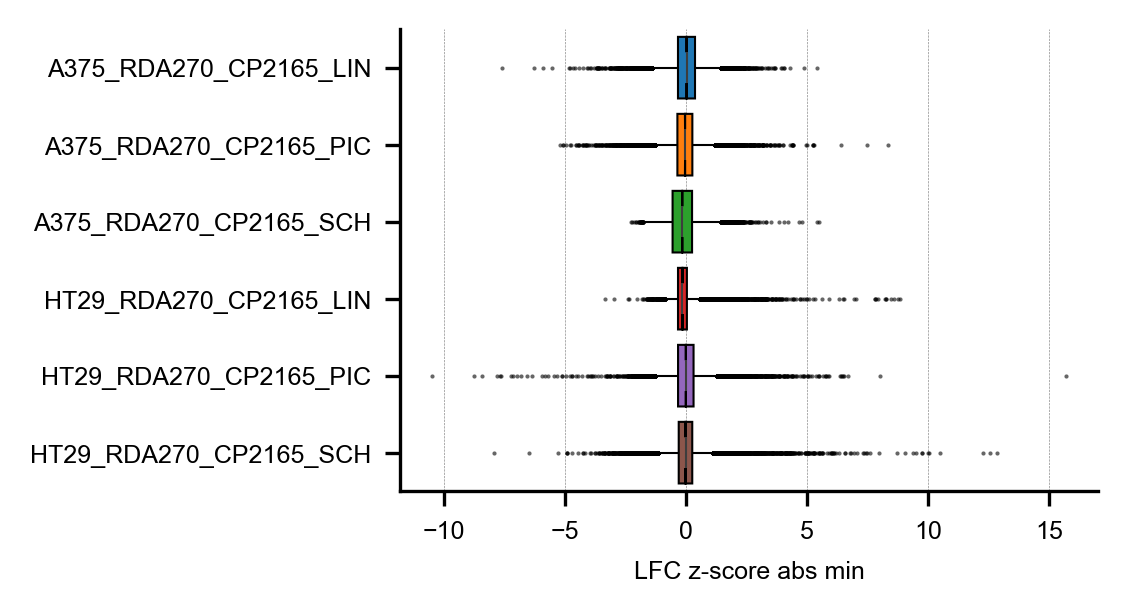

In [56]:
ax = boxplot_conditions(eg_lfc_zscore_min)
ax.set_xlabel("LFC z-score abs min")
plt.show()
plt.close("all")

In [57]:
mc_lfc_zscore_min = mc_lfc_zscore.groupby(
    mc_lfc_zscore.columns.str.rsplit("_", n=1).str[0], axis=1
).agg(lambda r: r.apply(lambda v: min(v, key=abs), axis=1))
mc_lfc_zscore_min

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_54582/2644740629.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mc_lfc_zscore_min = mc_lfc_zscore.groupby(


HT_29_Pict  HT_29_T0  HT_29_Tram  H_23_Adag  \
Guide                Gene Editor                                                
AAAAAAAAAAACTAAGAGTT KRAS ABE      -0.463185 -0.128870    0.240441   0.402865   
                          CBE       0.185809 -0.020508    0.893712   0.918930   
AAAAAAAAAAGTAAGCTTCA KRAS ABE       0.685501  0.292900    0.548344   0.362697   
                          CBE      -0.276330  0.047498   -0.109190  -0.355971   
AAAAAAAAAATCAATGGTGG BCL2 ABE       0.987539  0.068710    0.660686  -0.043889   
...                                      ...       ...         ...        ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE      -0.250978 -0.438190    0.164491  -0.119981   
TTTTGTGTGACAAAGCGTAA EGFR ABE      -0.082865 -0.182159    0.089059   0.312099   
                          CBE       0.311432  0.446267   -0.221087   0.427783   
TTTTGTTTCCTTGCTCACTG BRAF ABE      -0.256172  0.574937    1.016331   0.037052   
                          CBE       0.181405 -0.297557   -0.115765   0.359130   

                                  H_23_Sotor   H_23_T0  PC_9_Gefit  PC_9_Osim  \
Guide                Gene Editor                                                
AAAAAAAAAAACTAAGAGTT KRAS ABE       0.380066 -0.234905   -0.370766  -0.488558   
                          CBE      -0.479683  0.264746    0.562808  -0.098676   
AAAAAAAAAAGTAAGCTTCA KRAS ABE       0.661554 -0.935857   -0.265154  -0.331355   
                          CBE       0.167385  0.000072   -0.700069   0.832636   
AAAAAAAAAATCAATGGTGG BCL2 ABE       1.729693  0.380467    0.230422  -0.489591   
...                                      ...       ...         ...        ...   
TTTTGTGCCCTGGACAAAGT BRAF CBE       0.024459 -0.545753   -0.199172  -1.064643   
TTTTGTGTGACAAAGCGTAA EGFR ABE       0.915134  0.522599   -0.038007   0.531144   
                          CBE      -0.820618 -0.356686    0.242964  -0.157907   
TTTTGTTTCCTTGCTCACTG BRAF ABE      -0.902272 -0.016791   -0.568068  -0.236403   
                          CBE      -0.091159 -0.487575    0.176683  -0.217587   

                                   PC_9_T0  
Guide                Gene Editor            
AAAAAAAAAAACTAAGAGTT KRAS ABE    -0.000764  
                          CBE    -0.139718  
AAAAAAAAAAGTAAGCTTCA KRAS ABE    -0.492804  
                          CBE    -0.294012  
AAAAAAAAAATCAATGGTGG BCL2 ABE    -0.165081  
...                                    ...  
TTTTGTGCCCTGGACAAAGT BRAF CBE    -0.533876  
TTTTGTGTGACAAAGCGTAA EGFR ABE    -0.158619  
                          CBE    -0.495869  
TTTTGTTTCCTTGCTCACTG BRAF ABE    -0.572439  
                          CBE    -0.379423  

[45182 rows x 9 columns]

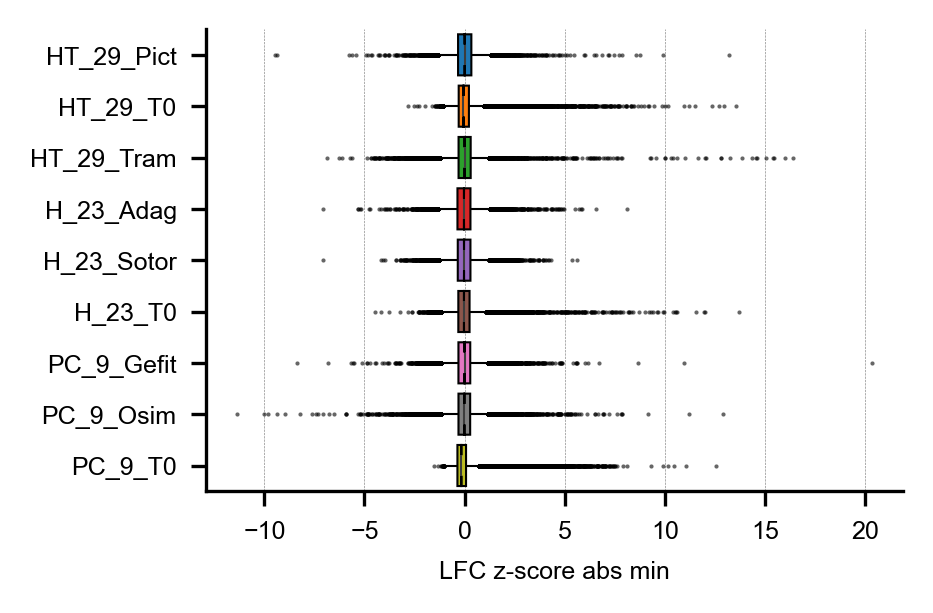

In [58]:
ax = boxplot_conditions(mc_lfc_zscore_min)
ax.set_xlabel("LFC z-score abs min")
plt.show()
plt.close("all")

## Correlations with percentage CG


### EG


In [59]:
percentages = pd.Series(
    eg_lfc.index.get_level_values(0).map(
        lambda x: (x.count("C") + x.count("G")) / len(x) * 100
    ),
    index=eg_lfc.index,
)
percentages

Guide                 Gene                Editor
AAAAGCCAAGTCTGAGACTG  ITGA3               CBE       45.0
AAACCAAAGGCAGAGCCACT  ITGA3               CBE       50.0
AAACTGTGGAGGATGTAGGA  ITGA3               CBE       45.0
AACAAGACCACGTGGGTGAG  ITGA3               CBE       55.0
AACATCACAGTGAAAAGTGA  ITGA3               CBE       35.0
                                                    ... 
CTATAGGCGCACGTTCGTTG  Intergenic control  CBE       55.0
GTATGAATATATCGCGCGAC  Intergenic control  CBE       45.0
CGACGCTAACGCGTCGGAAT  Intergenic control  CBE       60.0
TGGTAGTACTACGACGATAG  Intergenic control  CBE       45.0
ATAATAGCATCGTTACGCGC  Intergenic control  CBE       45.0
Name: Guide, Length: 39476, dtype: float64

In [60]:
_, axs = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True, sharex=True)

for i, y in enumerate(
    [
        eg_lfc_zscore.mean(1).rename("Mean Z-Scores LFC"),
        eg_lfc_zscore_min.mean(1).rename("Mean Abs Min Z-Scores LFC"),
    ]
):
    x, y = percentages, y.loc[percentages.index]
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    axs[i].scatter(
        x,
        y,
        c=z,
        s=10,
        alpha=0.5,
        linewidth=0,
        cmap="viridis",
        zorder=1,
    )

    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        color="salmon",
        line_kws={"label": "Linear Regression", "zorder": 2, "lw": 0.5},
        ax=axs[i],
    )

    r, p = pearsonr(percentages, y.loc[percentages.index])
    axs[i].annotate(
        f"r = {r:.2f}\np = {p:.2e}",
        xy=(0.99, 0.01),
        xycoords="axes fraction",
        ha="right",
        va="bottom",
        fontsize=6,
    )

    axs[i].set_ylabel(f"CBE")
    axs[i].set_xlabel(f"Percentage of C/G in sgRNA")
    axs[i].set_title(f"{y.name}", fontsize=7, y=0.9)

plt.tight_layout()
plt.savefig(
    f"reports/correlation/editing_window_correlation_EG.png",
    bbox_inches="tight",
    dpi=300,
)
plt.close("all")

### MC


In [61]:
percentages = pd.Series(
    mc_lfc.index.get_level_values(0).map(
        lambda x: (x.count("C") + x.count("G")) / len(x) * 100
    ),
    index=mc_lfc.index,
)
percentages

Guide                 Gene  Editor
AAAAAAAAAAACTAAGAGTT  KRAS  ABE       15.0
                            CBE       15.0
AAAAAAAAAAGTAAGCTTCA  KRAS  ABE       20.0
                            CBE       20.0
AAAAAAAAAATCAATGGTGG  BCL2  ABE       25.0
                                      ... 
TTTTGTGCCCTGGACAAAGT  BRAF  CBE       45.0
TTTTGTGTGACAAAGCGTAA  EGFR  ABE       35.0
                            CBE       35.0
TTTTGTTTCCTTGCTCACTG  BRAF  ABE       40.0
                            CBE       40.0
Name: Guide, Length: 45182, dtype: float64

In [62]:
fig, axs = plt.subplots(2, 2, figsize=(5, 5), sharey="row", sharex="all")

for i, y in enumerate(
    [
        mc_lfc_zscore.mean(1).rename("Mean Z-Scores LFC"),
        mc_lfc_zscore_min.mean(1).rename("Mean Abs Min Z-Scores LFC"),
    ]
):
    x, y = percentages, y.loc[percentages.index]

    for j, e in enumerate(["ABE", "CBE"]):
        y_e = y.loc[y.index.get_level_values(2).str.contains(e)]
        x_e = x.loc[y_e.index]

        xy_e = np.vstack([x_e, y_e])
        z_e = gaussian_kde(xy_e)(xy_e)

        axs[i][j].scatter(
            x_e,
            y_e,
            c=z_e,
            s=10,
            alpha=0.5,
            linewidth=0,
            cmap="viridis",
            zorder=1,
        )

        sns.regplot(
            x=x_e,
            y=y_e,
            scatter=False,
            color="salmon",
            line_kws={"label": "Linear Regression", "zorder": 2, "lw": 0.5},
            ax=axs[i][j],
        )

        r, p = pearsonr(x_e, y_e)
        axs[i][j].annotate(
            f"r = {r:.2f}\np = {p:.2e}",
            xy=(0.99, 0.01),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=6,
        )

        axs[i][j].set_ylabel(f"{e}")
        axs[i][j].set_xlabel(f"Percentage of C/G in sgRNA")
        axs[i][j].set_title(f"{y.name}", fontsize=7, y=0.9)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
fig.suptitle(f"MC", fontsize=7, y=0.95)
plt.tight_layout()

plt.savefig(
    f"reports/correlation/editing_window_correlation_MC.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close("all")

## Replicate correlation


In [63]:
be_fc_disc = pd.concat(
    [
        eg_lfc_zscore_min["HT29_RDA270_CP2165_PIC"].rename("EG"),
        mc_lfc_zscore_min["HT_29_Pict"].rename("MC"),
    ],
    axis=1,
).dropna()
be_fc_disc

,,,EG,MC
Guide,Gene,Editor,,
AAAACAGTTAGCCAGAGGTT,PIK3CA,CBE,-0.293217,-0.596639
AAAATATCTGGCAAAATCAA,PIK3CA,CBE,-0.211017,-0.210641
AAAATCAAGGTCTTGATCTT,PIK3CA,CBE,0.080872,0.860601
AAAATCTTTCTCCTGCTCAG,PIK3CA,CBE,-1.173213,-1.688221
AAAATTCTTTGTGCAACCTA,PIK3CA,CBE,-0.012326,-0.148583
...,...,...,...,...
TTTGAGAAGATCAGTGAGCT,MAP2K1,CBE,-0.871962,-0.087487
TTTGAGTTGTTGGATTACAT,MAP2K1,CBE,-0.830195,-0.092210
TTTGCAGCCTCCTCCAAAAC,MAP2K1,CBE,-0.583101,0.133665


### Scatter regression


In [64]:
x, y = be_fc_disc["EG"], be_fc_disc["MC"]
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

In [65]:
_, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

ax.scatter(
    x=x,
    y=y,
    c=z,
    s=10,
    alpha=0.5,
    linewidth=0,
    cmap="viridis",
    zorder=1,
)

sns.regplot(
    x=x,
    y=y,
    scatter=False,
    color="salmon",
    line_kws={"label": "Linear Regression", "zorder": 2, "lw": 0.5},
    ax=ax,
)

ax.axline((0, 0), lw=0.5, color="black", linestyle="--", slope=1)

offset = 0.1
ax.set_xlim(min(x.min(), y.min()) - offset, max(x.max(), y.max()) + offset)
ax.set_ylim(min(x.min(), y.min()) - offset, max(x.max(), y.max()) + offset)

r, p = pearsonr(x, y)
ax.annotate(
    f"r = {r:.2f}\np = {p:.2e}",
    xy=(0.99, 0.01),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=6,
)

ax.set_ylabel(f"MC")
ax.set_xlabel(f"EG")
ax.set_title(f"HT-29 + Pictilisib", fontsize=7, y=0.9)

plt.savefig(
    f"reports/correlation/correlation_EG_MC_HT29_Pic.png",
    bbox_inches="tight",
    dpi=300,
)
plt.close("all")

### Discretize


In [66]:
labels = ["negative", "neutral", "positive"]

In [67]:
def discretize_conditions(series):
    def categorize(value, q1, q3):
        if value < q1:
            return "negative"
        elif value > q3:
            return "positive"
        else:
            return "neutral"


    q1, q3 = series.quantile([0.15, 0.85])
    
    return series.apply(categorize, args=(q1, q3))

In [68]:
be_fc_disc = pd.concat([
    be_fc_disc, 
    discretize_conditions(eg_lfc_zscore_min["HT29_RDA270_CP2165_PIC"]).rename("EG_DISC"),
    discretize_conditions(mc_lfc_zscore_min["HT_29_Pict"]).rename("MC_DISC")
], axis=1).dropna()
be_fc_disc

,,,EG,MC,EG_DISC,MC_DISC
Guide,Gene,Editor,,,,
AAAACAGTTAGCCAGAGGTT,PIK3CA,CBE,-0.293217,-0.596639,neutral,negative
AAAATATCTGGCAAAATCAA,PIK3CA,CBE,-0.211017,-0.210641,neutral,neutral
AAAATCAAGGTCTTGATCTT,PIK3CA,CBE,0.080872,0.860601,neutral,positive
AAAATCTTTCTCCTGCTCAG,PIK3CA,CBE,-1.173213,-1.688221,negative,negative
AAAATTCTTTGTGCAACCTA,PIK3CA,CBE,-0.012326,-0.148583,neutral,neutral
...,...,...,...,...,...,...
TTTGAGAAGATCAGTGAGCT,MAP2K1,CBE,-0.871962,-0.087487,negative,neutral
TTTGAGTTGTTGGATTACAT,MAP2K1,CBE,-0.830195,-0.092210,negative,neutral
TTTGCAGCCTCCTCCAAAAC,MAP2K1,CBE,-0.583101,0.133665,negative,neutral


### Count number of hits


In [69]:
plot_df = be_fc_disc[["EG_DISC", "MC_DISC"]].apply(lambda col: col.value_counts()).unstack().fillna(0).astype(int).T.reset_index()
plot_df.columns = ["dataset", "hit", "count"]
plot_df

,dataset,hit,count
0,EG_DISC,neutral,4921
1,EG_DISC,negative,1157
2,EG_DISC,positive,1153
3,MC_DISC,neutral,5034
4,MC_DISC,negative,1338
5,MC_DISC,positive,859


In [70]:
_, ax = plt.subplots(1, 1, figsize=(1.5, 2))

sns.barplot(data=plot_df, x="hit", y="count", hue="dataset", ax=ax, palette="Set2", dodge=True)

ax.set_xlabel("")
ax.set_ylabel("Number of sgRNAs")

ax.legend(title="", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.savefig("reports/correlation/counts_barplot.png",     bbox_inches="tight",
    dpi=300)
plt.close("all")

### Confusion matrix


In [ ]:
cm = pd.DataFrame(
    confusion_matrix(be_fc_disc["EG_DISC"], be_fc_disc["MC_DISC"], labels=labels),
    index=labels,
    columns=labels,
)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(2, 2))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Blues_r",
    cbar=False,
    linewidths=0,
    xticklabels=cm.columns,
    yticklabels=cm.columns,
    ax=ax,
)

chi2, p_value, dof, expected = chi2_contingency(cm)

plt.title(f"Confusion Matrix\nChi2: {chi2:.2f}, p-value: {p_value:.2e}")

plt.xlabel("EG")
plt.ylabel("MC")

plt.savefig("reports/correlation/hits_confusion_matrix.png",     bbox_inches="tight",
    dpi=300)
plt.close("all")